In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('breast_cancer_2features.csv')

print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())
print("\nTarget value counts:")
print(df['target'].value_counts())
print("\n(0 = Malignant, 1 = Benign)")

Shape: (569, 3)

First 5 rows:
   mean radius  mean texture  target
0        17.99         10.38       0
1        20.57         17.77       0
2        19.69         21.25       0
3        11.42         20.38       0
4        20.29         14.34       0

Target value counts:
target
1    357
0    212
Name: count, dtype: int64

(0 = Malignant, 1 = Benign)


In [13]:
# Features and target
X = df[['mean radius', 'mean texture']]
y = df['target']  # 0 = Malignant, 1 = Benign

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")
print(f"\ny_train distribution:")
print(y_train.value_counts())

Training samples : 455
Testing  samples : 114

y_train distribution:
target
1    286
0    169
Name: count, dtype: int64


In [14]:
# Train Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Coefficients
print("Intercept  :", round(model.intercept_[0], 4))
print("Coefficients:")
for name, coef in zip(['mean radius', 'mean texture'], model.coef_[0]):
    print(f"  {name}: {round(coef, 6)}")

Intercept  : 0.6865
Coefficients:
  mean radius: -3.097385
  mean texture: -0.899163


In [15]:
# Predictions
y_pred = model.predict(X_test)
print("Predicted labels:", y_pred)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {acc:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                            target_names=['Malignant (0)', 'Benign (1)']))

Predicted labels: [1 0 0 1 1 0 0 0 1 1 1 0 0 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0
 1 0 0 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 1 1 1 0 0 0 1 1 0 0 1 1 1 0 1 0
 1 1 1 1 1 1 0 1 0 0 0 1 1 0 1 1 1 1 1 1 1 1 0 1 1 0 0 1 0 0 1 1 1 0 1 1 0
 1 0 0]

Test Accuracy: 0.9035

Classification Report:
               precision    recall  f1-score   support

Malignant (0)       0.90      0.84      0.87        43
   Benign (1)       0.91      0.94      0.92        71

     accuracy                           0.90       114
    macro avg       0.90      0.89      0.90       114
 weighted avg       0.90      0.90      0.90       114



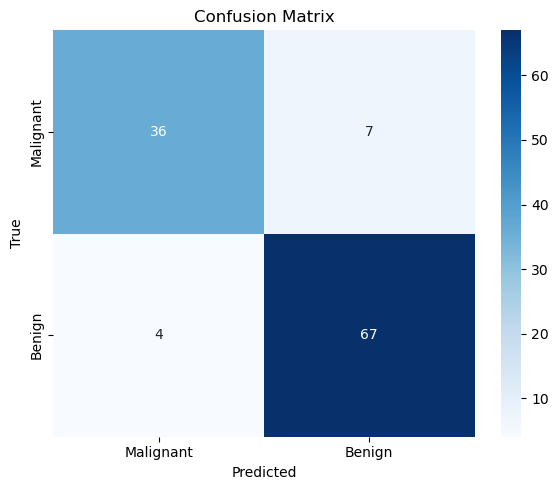

Confusion Matrix:
[[36  7]
 [ 4 67]]


In [16]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

print(f"Confusion Matrix:\n{cm}")

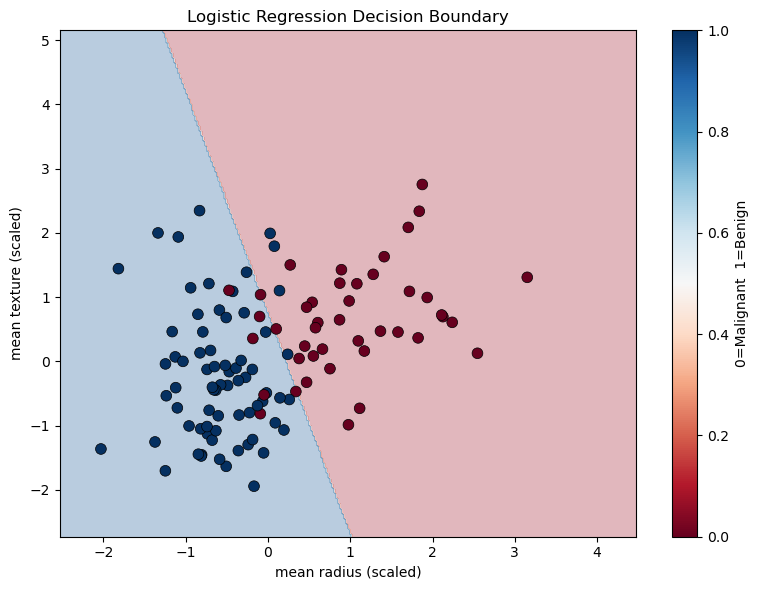

In [17]:
# Decision Boundary Plot
plt.figure(figsize=(8, 6))

# Create mesh grid
x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')

# Scatter the actual test points
scatter = plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test,
                      cmap='RdBu', edgecolors='k', linewidths=0.5, s=60)
plt.colorbar(scatter, label='0=Malignant  1=Benign')
plt.xlabel('mean radius (scaled)')
plt.ylabel('mean texture (scaled)')
plt.title('Logistic Regression Decision Boundary')
plt.tight_layout()
plt.show()